In [1]:
# Load MSK data (if not already loaded)
# Uncomment if needed:
import sys,os
import pandas as pd
import numpy as np
# Add parent directory to path to import modules from one level up
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../..'))
sys.path.insert(0, parent_dir)
import importlib
import public.model_IAI
importlib.reload(public.model_IAI)
from public.model_IAI import *
# Load the MSK dataset with enhanced cost features
df_og = pd.read_parquet("../msk_2017_18_full.parquet")


In [12]:
# MSK-specific feature column definitions
# Binary flag columns: comorbidity flags, MSK category flags, medication flags
BIN_FLAG_COLUMNS = get_bin_flag_columns(df_og)
print(BIN_FLAG_COLUMNS)

# Categorical columns
CAT_COLUMNS = get_cat_columns(df_og)
# True numeric columns (excluding binary flags and categorical)
TRUE_NUM_COLUMNS = get_true_num_columns(df_og, CAT_COLUMNS,BIN_FLAG_COLUMNS)
print(TRUE_NUM_COLUMNS)

# Cost columns (2017 only - exclude 2018 to prevent leakage)
COST_COLUMNS = [
    col for col in df_og.columns 
    if ("cost" in col.lower() or "quarterly" in col.lower() or "increasing" in col.lower() or 
        "decreasing" in col.lower() or "skewness" in col.lower() or "kurtosis" in col.lower() or
        "cv" in col.lower() or "range" in col.lower())
    and "2018" not in col  # Exclude 2018 columns to prevent leakage
]

# Utilization columns (if any)
UTILIZATION_COLUMNS = [col for col in df_og.columns if "claims" in col.lower() and "2018" not in col]
print("len(UTILIZATION_COLUMNS): ", len(UTILIZATION_COLUMNS))
print("categorical cols: ", CAT_COLUMNS[:10], f"... ({len(CAT_COLUMNS)} total)")
print("cost cols (sample): ", COST_COLUMNS[:10], f"... ({len(COST_COLUMNS)} total)")

leftover_cols = [
    c for c in df_og.columns 
    if c not in CAT_COLUMNS and c not in TRUE_NUM_COLUMNS and c not in BIN_FLAG_COLUMNS 
    and c != "ENROLID"
]

print(f"Number of leftover columns: {len(leftover_cols)}")
if len(leftover_cols) > 0:
    print("Leftover columns:", leftover_cols[:20])

# Create cost stratum from 2018 target (if available)
# Check what target columns are available
target_candidates = [col for col in df_og.columns if "2018" in col and ("top" in col.lower() or "pct" in col.lower() or "cost" in col.lower())]
print(f"\nAvailable 2018 target columns: {target_candidates}")

# Use top_2_pct_cost_2018 as target if available, otherwise create from annual_cost_2018_deflated
if "top_2_pct_cost_2018" in df_og.columns:
    target_col = "top_2_pct_cost_2018"
    print(f"Using {target_col} as target column")
elif "annual_cost_2018_deflated" in df_og.columns:
    # Create binary target from annual_cost_2018_deflated
    # Use 98th percentile as threshold (top 2%)
    threshold = df_og["annual_cost_2018_deflated"].quantile(0.98)
    df_og["top_2_pct_cost_2018"] = (df_og["annual_cost_2018_deflated"] >= threshold).astype(int)
    target_col = "top_2_pct_cost_2018"
    print(f"Created {target_col} using threshold ${threshold:,.2f}")
else:
    raise ValueError("No 2018 target column found. Need either 'top_2_pct_cost_2018' or 'annual_cost_2018_deflated'")

# Exclude all columns containing "2018" from features (to prevent leakage)
# Also exclude ENROLID and target column
exclude_cols = ["ENROLID", target_col] + [col for col in df_og.columns 
if "2018" in col] 
feature_cols = [c for c in df_og.columns if c not in exclude_cols]

print(f"\nTotal columns in dataset: {len(df_og.columns)}")
print(f"Columns excluded (leakage prevention): {len(exclude_cols)}, {exclude_cols[:10]}")
print(f"Feature columns: {len(feature_cols)}, {feature_cols[:10]}")

# Check for high correlation with target (optional - can be slow for large datasets)
if len(feature_cols) < 500:  # Only do this for reasonable number of features
    numeric_cols = df_og[feature_cols + [target_col]].select_dtypes(include=["number"]).columns
    if len(numeric_cols) > 0:
        corrs = df_og[numeric_cols].corr()[target_col].abs().sort_values(ascending=False)
        # Columns to drop (very high correlation, likely leakage)
        high_corr_cols = corrs[corrs > 0.95].index.tolist()
        # Remove the target column itself, if present
        high_corr_cols = [col for col in high_corr_cols if col != target_col]
        # Final filtered feature set
        feature_cols = [col for col in feature_cols if col not in high_corr_cols]
        if len(high_corr_cols) > 0:
            print(f"High corr features dropped (corr > 0.95): {high_corr_cols}")

print(f"\nFinal feature count: {len(feature_cols)}")
print(f"Target column: {target_col}")
print(f"Target distribution:\n{df_og[target_col].value_counts()}")

['has_Anemia', 'has_Atherosclerotic_Heart_Disease', 'has_Chronic_Pain', 'has_Depression_Anxiety', 'has_Gastroesophageal_Reflux_Disease', 'has_General_Health_Check', 'has_Hyperlipidemia', 'has_Hypertension', 'has_Long_term_Drug_Therapy', 'has_Obesity', 'has_Sleep_Apnea', 'has_Type_2_Diabetes', 'has_Vitamin_D_Deficiency', 'has_Arthropathies', 'has_Dorsopathies', 'has_Soft_tissue', 'has_Osteopathies', 'has_Other_MSK', 'direct_msk_is_increasing_Q1_Q2_2017', 'direct_msk_is_increasing_Q2_Q3_2017', 'direct_msk_is_increasing_Q3_Q4_2017', 'msk_procedure_is_increasing_Q1_Q2_2017', 'msk_procedure_is_increasing_Q2_Q3_2017', 'msk_procedure_is_increasing_Q3_Q4_2017', 'comorbidity_only_is_increasing_Q1_Q2_2017', 'comorbidity_only_is_increasing_Q2_Q3_2017', 'comorbidity_only_is_increasing_Q3_Q4_2017', 'has_Antihistamines_Comb_', 'has_Anti_Infective_Agents', 'has_Autonomic_Drugs', 'has_Blood_Form_Coagul_Agents', 'has_Cardiovascular_Agents', 'has_Central_Nervous_System', 'has_Diagnostic_Agents', 'has_El

In [3]:
# Split data into train/test/val (same as multiobjective_bilevel.ipynb)
# Use the target_col defined in cell 0
TRAIN_TEST_SEED = 123
train_ids, test_ids, train_pd, test_pd = train_test_split_enrol(
    df_og,
    target_col=target_col,  # Use target_col from cell 0 (e.g., "top_2_pct_cost_2018")
    test_size=0.3,
    verbose=False,
    random_state=TRAIN_TEST_SEED
)
print(f"Train shape: {train_pd.shape}, Test shape: {test_pd.shape}")
print("Feature cols:", len(feature_cols))

val_ids, test_ids, val_pd, test_pd = train_test_split_enrol(
    test_pd, 
    target_col=target_col,
    test_size=0.5,
    verbose=False, 
    random_state=TRAIN_TEST_SEED
)
X_test = test_pd[feature_cols]
y_test = test_pd[target_col]
X_val = val_pd[feature_cols]
y_val = val_pd[target_col]

print(f"Train: {train_pd.shape}, Val: {val_pd.shape}, Test: {test_pd.shape}")
print(f"Train target distribution:\n{train_pd[target_col].value_counts()}")
print(f"Target column: {target_col}")

Train shape: (175777, 115), Test shape: (75333, 115)
Feature cols: 110
Train: (175777, 115), Val: (37666, 115), Test: (37667, 115)
Train target distribution:
top_2_pct_cost_2018
0    172381
1      3396
Name: count, dtype: int64
Target column: top_2_pct_cost_2018


### TF-IDF + QuantileTransform preprocessing preview

Visualize how the Stage A pipeline transforms:
- **Binary codes** → TF-IDF weighting → IDF distribution
- **Cost features** → QuantileTransformer (output_distribution="normal") → before vs after

['has_Anemia', 'has_Atherosclerotic_Heart_Disease', 'has_Chronic_Pain', 'has_Depression_Anxiety', 'has_Gastroesophageal_Reflux_Disease', 'has_General_Health_Check', 'has_Hyperlipidemia', 'has_Hypertension', 'has_Long_term_Drug_Therapy', 'has_Obesity', 'has_Sleep_Apnea', 'has_Type_2_Diabetes', 'has_Vitamin_D_Deficiency', 'has_Arthropathies', 'has_Dorsopathies', 'has_Soft_tissue', 'has_Osteopathies', 'has_Other_MSK', 'direct_msk_is_increasing_Q1_Q2_2017', 'direct_msk_is_increasing_Q2_Q3_2017', 'direct_msk_is_increasing_Q3_Q4_2017', 'msk_procedure_is_increasing_Q1_Q2_2017', 'msk_procedure_is_increasing_Q2_Q3_2017', 'msk_procedure_is_increasing_Q3_Q4_2017', 'comorbidity_only_is_increasing_Q1_Q2_2017', 'comorbidity_only_is_increasing_Q2_Q3_2017', 'comorbidity_only_is_increasing_Q3_Q4_2017', 'has_Antihistamines_Comb_', 'has_Anti_Infective_Agents', 'has_Autonomic_Drugs', 'has_Blood_Form_Coagul_Agents', 'has_Cardiovascular_Agents', 'has_Central_Nervous_System', 'has_Diagnostic_Agents', 'has_El

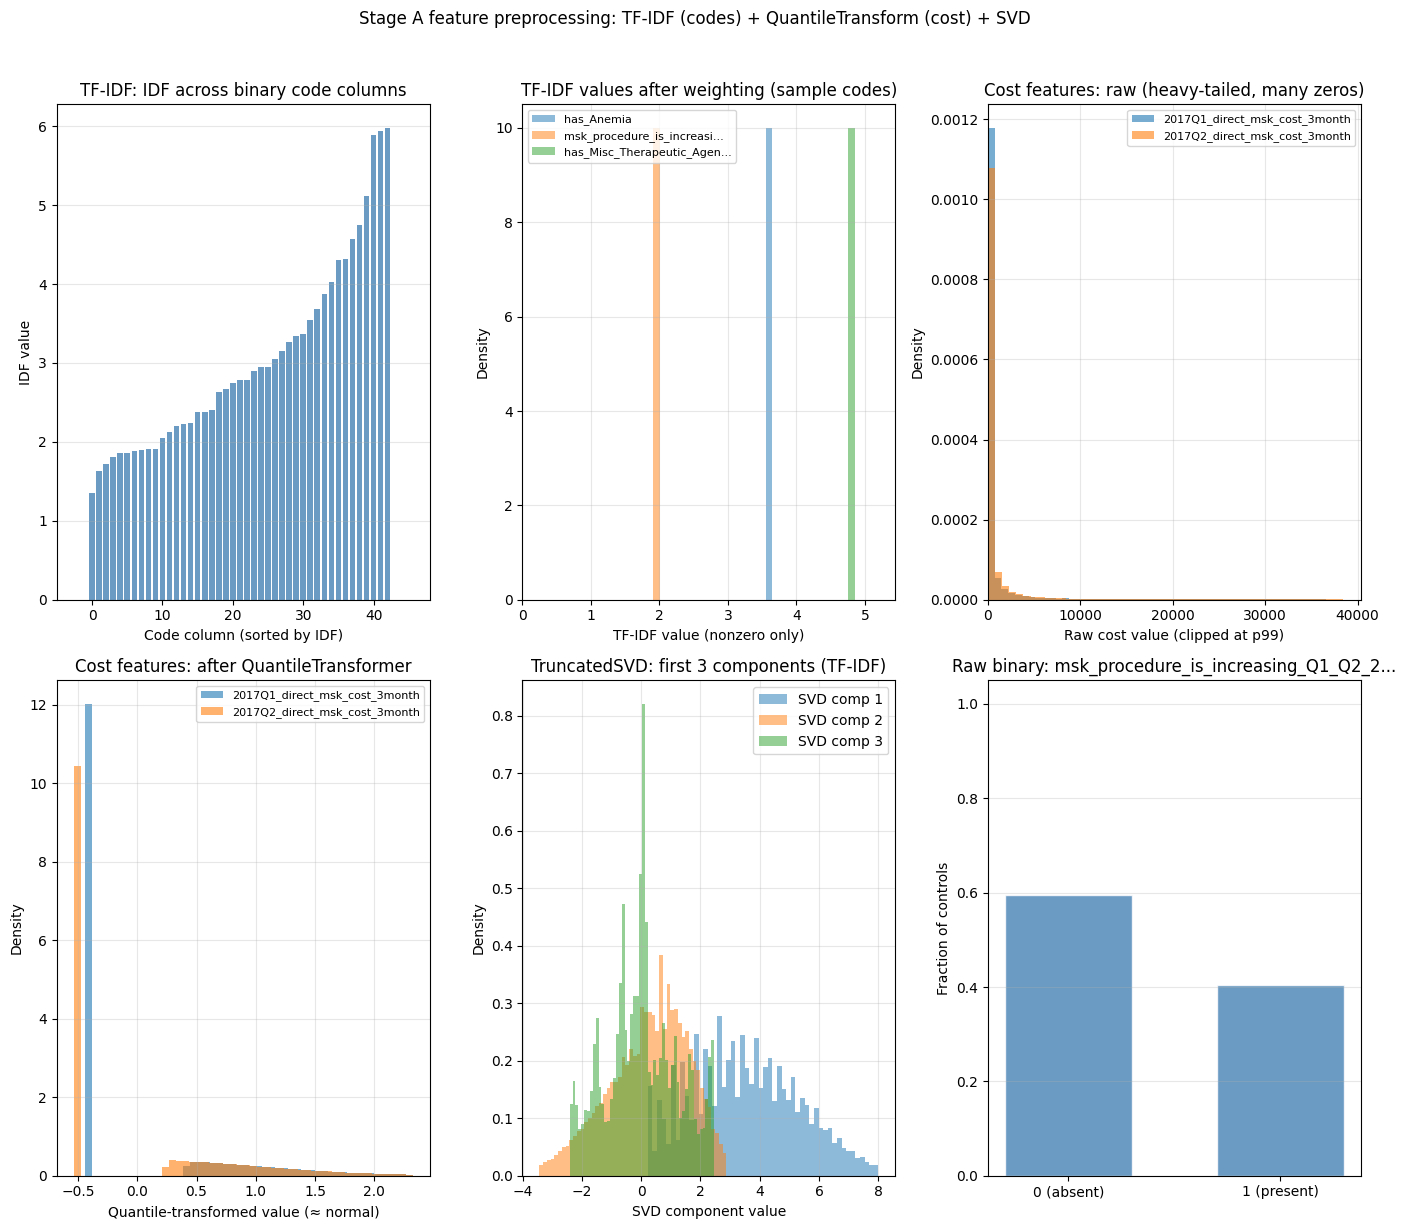

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from sklearn.preprocessing import QuantileTransformer

# Ensure scripts dir on path (tfidf_svd_qcost_embedding lives in scripts/)
for d in [os.getcwd(), os.path.join(os.getcwd(), "scripts"), os.path.dirname(os.path.abspath("."))]:
    if os.path.exists(os.path.join(d, "tfidf_svd_qcost_embedding.py")):
        sys.path.insert(0, d)
        break
import importlib
import tfidf_svd_qcost_embedding
importlib.reload(tfidf_svd_qcost_embedding)
from tfidf_svd_qcost_embedding import get_cost_columns_2017

# Controls (same as Stage A pipeline)
controls = train_pd[train_pd[target_col] == 0].copy()
code_cols = [c for c in BIN_FLAG_COLUMNS if c in feature_cols]
cost_cols_2017 = get_cost_columns_2017(controls)
if not code_cols or not cost_cols_2017:
    raise ValueError("Need code_cols and cost_cols_2017. Run the feature setup cell first.")
X_codes = controls[code_cols].fillna(0).values.astype(np.float64)
X_codes_sp = csr_matrix(X_codes)
n_controls = len(controls)

# 1) TF-IDF: IDF values and document frequency
df_j = np.array((X_codes_sp > 0).sum(axis=0)).flatten()
idf = np.log((n_controls + 1) / (df_j + 1)) + 1
X_tfidf = X_codes_sp.multiply(idf)

# 2) QuantileTransformer on cost columns
X_cost = controls[cost_cols_2017].fillna(0).values.astype(np.float64)
n_q = min(1000, n_controls)
subsamp = min(200_000, n_controls) if n_controls > 200_000 else None
qt = QuantileTransformer(output_distribution="normal", n_quantiles=n_q, subsample=subsamp, random_state=123)
Z_cost = qt.fit_transform(X_cost)

# 3) TruncatedSVD on TF-IDF (first few components for preview)
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=len(code_cols), random_state=123, n_iter=7)
Z_codes = svd.fit_transform(X_tfidf)

# --- Figures: clean, readable axes ---
fig = plt.figure(figsize=(14, 12))
print(code_cols)
# A) IDF distribution across code columns
ax1 = fig.add_subplot(2, 3, 1)
ax1.bar(range(len(idf)), np.sort(idf), color="steelblue", alpha=0.8, width=0.8)
ax1.set_xlabel("Code column (sorted by IDF)")
ax1.set_ylabel("IDF value")
ax1.set_title("TF-IDF: IDF across binary code columns")
ax1.set_xlim(-5, len(idf) + 5)
ax1.set_ylim(0, max(idf) * 1.05)
ax1.grid(axis="y", alpha=0.3)

# B) TF-IDF values for 3 sample code columns (nonzero only)
ax2 = fig.add_subplot(2, 3, 2)
sample_idx = [0, len(code_cols) // 2, len(code_cols) - 1]
for i, j in enumerate(sample_idx):
    tfidf_col = X_tfidf.getcol(j).toarray().flatten()
    tfidf_vals = np.asarray(tfidf_col).flatten()
    tfidf_nonzero = tfidf_vals[tfidf_vals > 0]
    if len(tfidf_nonzero) > 0:
        lab = code_cols[j][:25] + ("..." if len(code_cols[j]) > 25 else "")
        ax2.hist(tfidf_nonzero, bins=min(30, max(10, len(np.unique(tfidf_nonzero)) * 2)), alpha=0.5, label=lab, density=True)
ax2.set_xlabel("TF-IDF value (nonzero only)")
ax2.set_ylabel("Density")
ax2.set_title("TF-IDF values after weighting (sample codes)")
ax2.legend(fontsize=8)
ax2.set_xlim(left=0)
ax2.grid(alpha=0.3)

# C) Raw cost: 2 sample columns (heavy-tailed, many zeros)
ax3 = fig.add_subplot(2, 3, 3)
sample_cost_idx = [0, min(3, len(cost_cols_2017) - 1)]
for i, j in enumerate(sample_cost_idx):
    col = cost_cols_2017[j]
    raw = controls[col].fillna(0).values
    raw = raw[raw >= 0]
    p99 = max(np.percentile(raw, 99), 1e-6)  # avoid zero range
    raw_clip = raw[raw <= p99]
    ax3.hist(raw_clip, bins=50, alpha=0.6, label=col[:30] + ("..." if len(col) > 30 else ""), density=True, range=(0, p99))
ax3.set_xlabel("Raw cost value (clipped at p99)")
ax3.set_ylabel("Density")
ax3.set_title("Cost features: raw (heavy-tailed, many zeros)")
ax3.legend(fontsize=8)
ax3.set_xlim(0, None)
ax3.set_yscale("linear")
ax3.grid(alpha=0.3)

# D) After QuantileTransformer (roughly normal)
ax4 = fig.add_subplot(2, 3, 4)
for i, j in enumerate(sample_cost_idx):
    z = Z_cost[:, j]
    z = z[~np.isnan(z) & ~np.isinf(z)]
    p1, p99 = np.percentile(z, [1, 99])
    z_clip = z[(z >= p1) & (z <= p99)]
    ax4.hist(z_clip, bins=50, alpha=0.6, label=cost_cols_2017[j][:30] + ("..." if len(cost_cols_2017[j]) > 30 else ""), density=True)
ax4.set_xlabel("Quantile-transformed value (≈ normal)")
ax4.set_ylabel("Density")
ax4.set_title("Cost features: after QuantileTransformer")
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

# E) TruncatedSVD: distribution of first 3 components
ax5 = fig.add_subplot(2, 3, 5)
for comp in range(min(3, Z_codes.shape[1])):
    z = Z_codes[:, comp]
    z_clean = z[~np.isnan(z) & ~np.isinf(z)]
    p1, p99 = np.percentile(z_clean, [1, 99])
    z_clip = z_clean[(z_clean >= p1) & (z_clean <= p99)]
    ax5.hist(z_clip, bins=50, alpha=0.5, label=f"SVD comp {comp+1}", density=True)
ax5.set_xlabel("SVD component value")
ax5.set_ylabel("Density")
ax5.set_title("TruncatedSVD: first 3 components (TF-IDF)")
ax5.legend()
ax5.grid(alpha=0.3)

# F) Raw binary code sparsity (sample column)
ax6 = fig.add_subplot(2, 3, 6)
j = len(code_cols) // 2
raw_bin = X_codes[:, j]
frac0, frac1 = (raw_bin == 0).mean(), (raw_bin == 1).mean()
ax6.bar([0, 1], [frac0, frac1], color="steelblue", alpha=0.8, edgecolor="white", width=0.6)
ax6.set_xticks([0, 1])
ax6.set_xticklabels(["0 (absent)", "1 (present)"])
ax6.set_ylabel("Fraction of controls")
ax6.set_title(f"Raw binary: {code_cols[j][:35]}" + ("..." if len(code_cols[j]) > 35 else ""))
ax6.set_ylim(0, 1.05)
ax6.grid(axis="y", alpha=0.3)

plt.suptitle("Stage A feature preprocessing: TF-IDF (codes) + QuantileTransform (cost) + SVD", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Post-scaled continuous features: ours vs random vs max-disp

Compare boxplots of post-scaled (StandardScaler) continuous features across undersampled sets: Ours 1:1 (ZA+ZB), Random (Exp5), Max-disp (Exp6 cosine).

In [ ]:
meds_cols = ['has_Antihistamines_Comb_', 'has_Anti_Infective_Agents', 'has_Autonomic_Drugs', 'has_Blood_Form_Coagul_Agents', 'has_Cardiovascular_Agents', 'has_Central_Nervous_System', 'has_Diagnostic_Agents', 'has_Electrolytic_Caloric_Water', 'has_Respiratory_Tract_Agents', 'has_Eye_Ear_Nose_Throat', 'has_Gastrointestinal_Drugs', 'has_Hormones_Synthetic_Subst', 'has_Immunosuppressants', 'has_Skin_Mucous_Membrane', 'has_Vitamins_Comb', 'has_Misc_Therapeutic_Agents'] 
feature_cols = [c for c in feature_cols if c not in meds_cols]

In [ ]:
ours_pd = pd.read_csv("/Users/cat2510/my_projects/msk_analysis/exp6_distance_ablation/results/ours_1to1_A_za_coarse_phenotype__B_zb_intensity_context.csv")
rand_pd = pd.read_csv("/Users/cat2510/my_projects/msk_analysis/exp6_distance_ablation/results/exp5_s0.csv")
max_disp = pd.read_csv("/Users/cat2510/my_projects/msk_analysis/exp6_distance_ablation/results/exp6_cosine_s0.csv")
train_pd = max_disp.copy()
print(train_pd["2017Q1_comorbidity_only_cost_3month"].max(),train_pd["2017Q1_comorbidity_only_cost_3month"].min(),train_pd["2017Q1_comorbidity_only_cost_3month"].std())
majority_df = train_pd[train_pd["top_2_pct_cost_2018"] == 0].copy()
minority_df = train_pd[train_pd["top_2_pct_cost_2018"] == 1].copy()
majority_df["has_Anemia"].value_counts(normalize=True).head(10),minority_df["has_Anemia"].value_counts(normalize=True).head(10)
#len(majority_df)

279404.30000000005 0.0 6159.617042852647


(has_Anemia
 0    0.820573
 1    0.179427
 Name: proportion, dtype: float64,
 has_Anemia
 0    0.684629
 1    0.315371
 Name: proportion, dtype: float64)

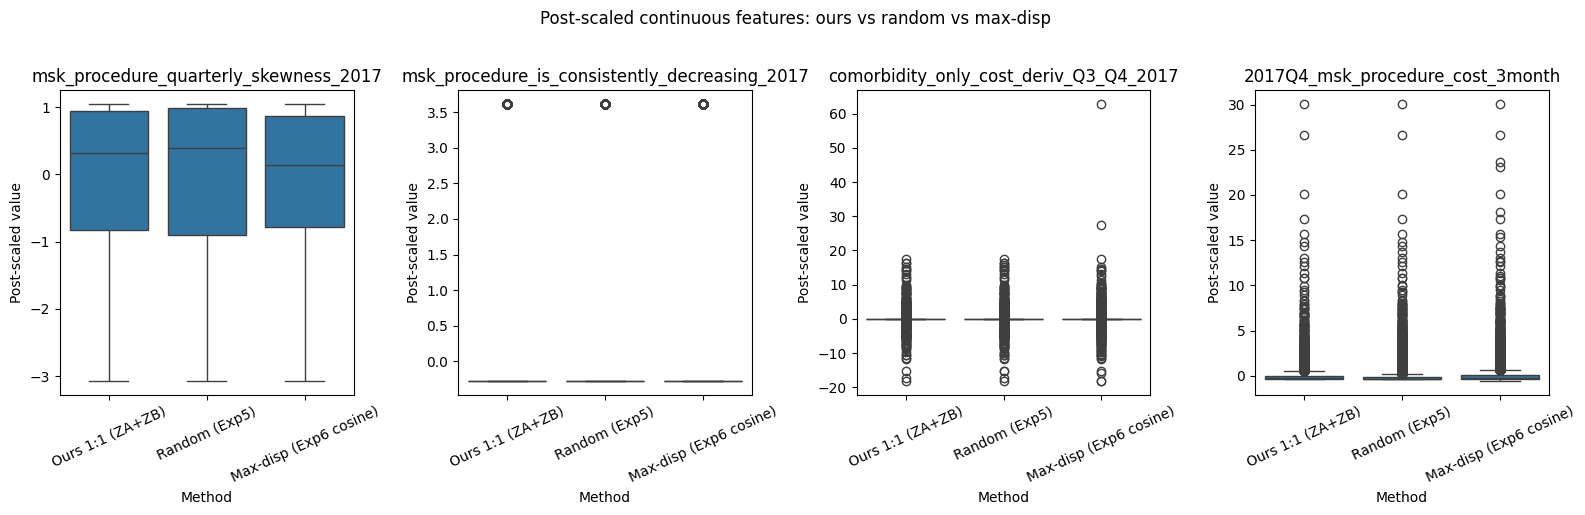

In [ ]:
# Post-scaled continuous feature boxplots: compare undersampled sets (ours vs rand vs max_disp)
import matplotlib.pyplot as plt
import seaborn as sns

# Load undersampled sets (or use already loaded ours_pd, rand_pd, max_disp)
ours_pd = pd.read_csv("/Users/cat2510/my_projects/msk_analysis/exp6_distance_ablation/results/ours_1to1_s0.csv")
rand_pd = pd.read_csv("/Users/cat2510/my_projects/msk_analysis/exp6_distance_ablation/results/exp5_s0.csv")
max_disp = pd.read_csv("/Users/cat2510/my_projects/msk_analysis/exp6_distance_ablation/results/exp6_cosine_s0.csv")

# Continuous columns for plotting
import random
cand = [c for c in TRUE_NUM_COLUMNS if c not in exclude_cols and c in feature_cols]
k = min(4, len(cand))
sel = random.sample(cand, k) if k else cand

# Fit preprocessor on concatenation of all three sets (neutral scaling)
fit_ref = pd.concat([ours_pd, rand_pd, max_disp], ignore_index=True)
preprocessor = get_preprocessor_with_impute(
    X_train=fit_ref[feature_cols],
    categorical_cols=[c for c in CAT_COLUMNS if c in feature_cols],
    numeric_cols=[c for c in TRUE_NUM_COLUMNS if c in feature_cols],
    binary_cols=[c for c in BIN_FLAG_COLUMNS if c in feature_cols],
    verbose=False,
)
preprocessor.fit_transform(fit_ref[feature_cols])

# Get column indices for numeric block in transformed output
ct = preprocessor
cat_cols_ct = [c for c in CAT_COLUMNS if c in feature_cols and c in fit_ref.columns]
num_start = 0
if cat_cols_ct and "cat" in ct.named_transformers_:
    cat_out = ct.named_transformers_["cat"].transform(fit_ref[cat_cols_ct])
    num_start = cat_out.shape[1]
num_cols_order = [c for c in TRUE_NUM_COLUMNS if c in feature_cols]
col_to_idx = {c: num_start + i for i, c in enumerate(num_cols_order)}
sel_in_num = [c for c in sel if c in col_to_idx]

# Transform each undersampled set and collect post-scaled values
sets = [
    ("Ours 1:1 (ZA+ZB)", ours_pd),
    ("Random (Exp5)", rand_pd),
    ("Max-disp (Exp6 cosine)", max_disp),
]
plot_rows = []
for method, df in sets:
    cols_avail = [c for c in feature_cols if c in df.columns]
    if len(cols_avail) < len(feature_cols):
        df = df.reindex(columns=feature_cols).fillna(0)
    X_t = preprocessor.transform(df[feature_cols])
    for col in sel_in_num:
        idx = col_to_idx[col]
        vals = X_t[:, idx].astype(float)
        vals = vals[~np.isnan(vals) & ~np.isinf(vals)]
        lab = col[:40] + ("..." if len(col) > 40 else "")
        for v in vals:
            plot_rows.append({"Method": method, "Feature": lab, "ScaledValue": v})

plot_df = pd.DataFrame(plot_rows)

# Boxplots: one subplot per feature
n_feat = len(sel_in_num)
fig, axes = plt.subplots(1, n_feat, figsize=(4 * n_feat, 5), squeeze=False)
for i, col in enumerate(sel_in_num):
    ax = axes[0, i]
    lab = col[:40] + ("..." if len(col) > 40 else "")
    sub = plot_df[plot_df["Feature"] == lab]
    sns.boxplot(data=sub, x="Method", y="ScaledValue", ax=ax, showfliers=False)
    ax.set_title(col[:45] + ("..." if len(col) > 45 else ""))
    ax.set_ylabel("Post-scaled value")
    ax.tick_params(axis="x", rotation=25)
plt.suptitle("Post-scaled continuous features: ours vs random vs max-disp", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Per-feature distance contributions (majority–minority vs majority–majority)

Subset majority/minority, sample pairs, compute per-feature L1 contributions |x_i - x_j| to find which features dominate pairwise distance sums.

Per-feature distance contributions (metric=gower) – top 20 by maj–min:
                                       feature  mean_maj_min  mean_maj_maj  median_maj_min  median_maj_maj  ratio_mean
6                           has_Hyperlipidemia      0.509128      0.502797             1.0             1.0    1.012592
21      msk_procedure_is_increasing_Q1_Q2_2017      0.506920      0.499411             1.0             0.0    1.015035
33  msk_procedure_cost_stability_2017_moderate      0.506773      0.485571             1.0             0.0    1.043663
42                                    AGEGRP_5      0.501178      0.504859             1.0             1.0    0.992709
44                                       SEX_2      0.500736      0.502797             1.0             1.0    0.995900
20         direct_msk_is_increasing_Q3_Q4_2017      0.498822      0.477768             0.0             0.0    1.044068
9                                  has_Obesity      0.496172      0.464075             0.0      

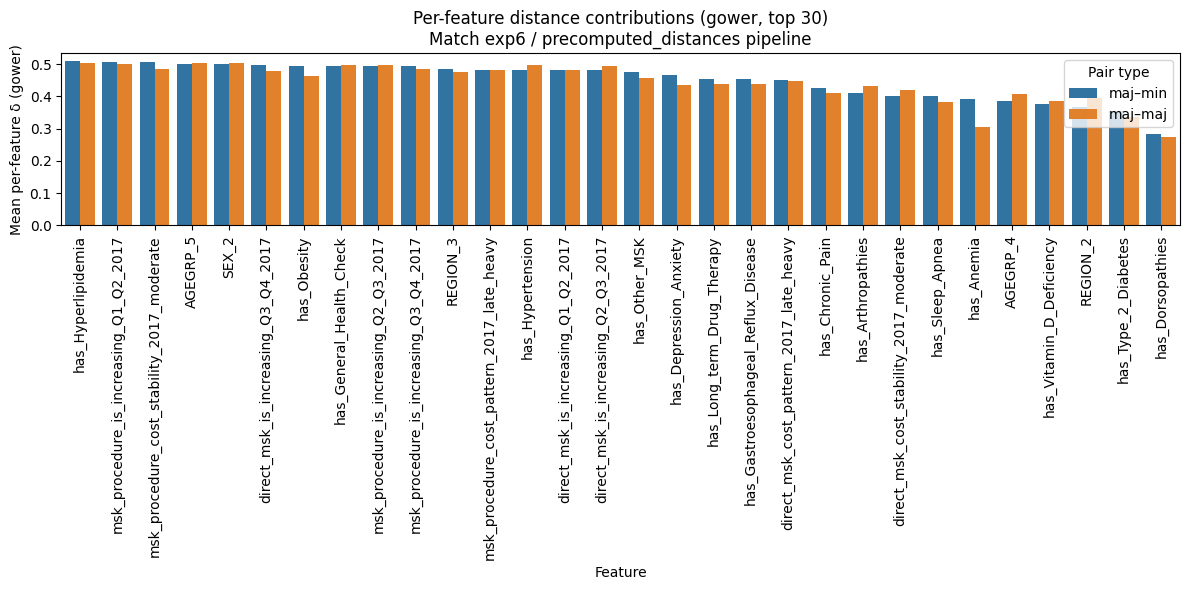

In [32]:
"""
Per-feature distance contributions – matches exp6_distance_metric_ablation pipeline.
Gower: δ=1[a≠b] for binary/OHE, δ=|a-b|/range_j for numeric (same as precomputed_distances_exp6_ablation).
Manhattan: preprocessor output, per-feature = |x_i - x_j|.
Paste this into the sparsity_histogram notebook cell to replace the broken per-feature analysis.
"""
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

METRIC = "gower"  # "gower" or "manhattan"
np.random.seed(42)
N_MIN = int(train_pd[target_col].sum())
N_MAJ = N_MIN
N_PAIRS = N_MIN*2

bin_cols = [c for c in BIN_FLAG_COLUMNS if c in feature_cols]
cat_cols = [c for c in CAT_COLUMNS if c in feature_cols]
num_cols = [c for c in TRUE_NUM_COLUMNS if c in feature_cols]
maj_df = train_pd[train_pd[target_col] == 0].reset_index(drop=True)
min_df = train_pd[train_pd[target_col] == 1].reset_index(drop=True)
maj_sub = maj_df.sample(n=min(N_MAJ, len(maj_df)), random_state=42).reset_index(drop=True)
min_sub = min_df.sample(n=min(N_MIN, len(min_df)), random_state=42).reset_index(drop=True)

if METRIC == "gower":
    parts_maj, parts_min, feat_names = [], [], []
    n_bin = 0
    if bin_cols:
        parts_maj.append(maj_sub[bin_cols].values.astype(np.float64))
        parts_min.append(min_sub[bin_cols].values.astype(np.float64))
        feat_names.extend(bin_cols)
        n_bin += len(bin_cols)
    if cat_cols:
        all_cat = pd.concat([maj_sub[cat_cols], min_sub[cat_cols]], ignore_index=True)
        ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
        ohe_mat = ohe.fit_transform(all_cat)
        parts_maj.append(ohe_mat[: len(maj_sub)].astype(np.float64))
        parts_min.append(ohe_mat[len(maj_sub) :].astype(np.float64))
        feat_names.extend(list(ohe.get_feature_names_out(cat_cols)))
        n_bin += ohe_mat.shape[1]
    if num_cols:
        parts_maj.append(maj_sub[num_cols].values.astype(np.float64))
        parts_min.append(min_sub[num_cols].values.astype(np.float64))
        feat_names.extend(num_cols)
    X_maj = np.hstack(parts_maj) if parts_maj else np.zeros((len(maj_sub), 0))
    X_min = np.hstack(parts_min) if parts_min else np.zeros((len(min_sub), 0))
    ranges = np.ones(X_maj.shape[1])
    for j in range(n_bin, X_maj.shape[1]):
        col = np.concatenate([X_maj[:, j], X_min[:, j]])
        r = float(np.nanmax(col) - np.nanmin(col))
        ranges[j] = r if r > 0 else 1.0
    bin_col_indices = list(range(n_bin))
else:
    preprocessor = get_preprocessor_with_impute(
        X_train=train_pd[feature_cols],
        categorical_cols=cat_cols,
        numeric_cols=num_cols,
        binary_cols=bin_cols,
        verbose=False,
    )
    X_maj = preprocessor.fit_transform(maj_sub[feature_cols])
    X_min = preprocessor.transform(min_sub[feature_cols])
    feat_names = []
    ct = preprocessor
    for name, trans, cols in ct.transformers_:
        if name == "cat" and hasattr(trans, "named_steps"):
            ohe = trans.named_steps.get("ohe")
            if ohe is not None and hasattr(ohe, "get_feature_names_out"):
                feat_names.extend(list(ohe.get_feature_names_out(cols)))
            else:
                feat_names.extend([f"cat_{c}" for c in cols])
        elif name == "num":
            feat_names.extend(cols)
        elif name == "binary":
            feat_names.extend(cols)
    if len(feat_names) != X_maj.shape[1]:
        feat_names = [f"f{j}" for j in range(X_maj.shape[1])]
    bin_col_indices = []
    ranges = np.ones(X_maj.shape[1])

X_maj = np.asarray(X_maj, dtype=np.float64)
X_min = np.asarray(X_min, dtype=np.float64)
n_feat = X_maj.shape[1]


def sample_per_feature_gower(X_maj, X_min, bin_idx, ranges, n_pairs):
    perm_m = np.random.choice(X_maj.shape[0], n_pairs, replace=True)
    perm_n = np.random.choice(X_min.shape[0], n_pairs, replace=True)
    diffs = np.zeros((n_pairs, n_feat), dtype=np.float64)
    for j in range(n_feat):
        a, b = X_maj[perm_m, j], X_min[perm_n, j]
        if METRIC == "gower" and j in set(bin_idx):
            diffs[:, j] = (a != b).astype(np.float64)
        elif METRIC == "gower":
            diffs[:, j] = np.abs(a - b) / (ranges[j] if ranges[j] > 0 else 1.0)
        else:
            diffs[:, j] = np.abs(a - b)
    return diffs


def sample_maj_maj_gower(X_maj, bin_idx, ranges, n_pairs):
    i = np.random.choice(X_maj.shape[0], n_pairs, replace=True)
    j = np.random.choice(X_maj.shape[0], n_pairs, replace=True)
    mask = i == j
    j[mask] = (j[mask] + 1) % X_maj.shape[0]
    diffs = np.zeros((n_pairs, n_feat), dtype=np.float64)
    for k in range(n_feat):
        a, b = X_maj[i, k], X_maj[j, k]
        if METRIC == "gower" and k in set(bin_idx):
            diffs[:, k] = (a != b).astype(np.float64)
        elif METRIC == "gower":
            diffs[:, k] = np.abs(a - b) / (ranges[k] if ranges[k] > 0 else 1.0)
        else:
            diffs[:, k] = np.abs(a - b)
    return diffs


diffs_maj_min = sample_per_feature_gower(X_maj, X_min, bin_col_indices, ranges, N_PAIRS)
diffs_maj_maj = sample_maj_maj_gower(X_maj, bin_col_indices, ranges, N_PAIRS)

mean_maj_min = np.nanmean(diffs_maj_min, axis=0)
mean_maj_maj = np.nanmean(diffs_maj_maj, axis=0)
median_maj_min = np.nanmedian(diffs_maj_min, axis=0)
median_maj_maj = np.nanmedian(diffs_maj_maj, axis=0)

summary = pd.DataFrame({
    "feature": feat_names,
    "mean_maj_min": mean_maj_min,
    "mean_maj_maj": mean_maj_maj,
    "median_maj_min": median_maj_min,
    "median_maj_maj": median_maj_maj,
})
summary["ratio_mean"] = summary["mean_maj_min"] / (summary["mean_maj_maj"] + 1e-10)
summary = summary.sort_values("mean_maj_min", ascending=False)
print(f"Per-feature distance contributions (metric={METRIC}) – top 20 by maj–min:")
print(summary.head(20).to_string())
print("\nTop 20 by mean (maj–maj):")
print(summary.sort_values("mean_maj_maj", ascending=False).head(20).to_string())

top_n = min(30, len(summary))
plot_df = summary.head(top_n).melt(
    id_vars=["feature"], value_vars=["mean_maj_min", "mean_maj_maj"],
    var_name="pair_type", value_name="mean_dist"
)
plot_df["pair_type"] = plot_df["pair_type"].replace({"mean_maj_min": "maj–min", "mean_maj_maj": "maj–maj"})
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=plot_df, x="feature", y="mean_dist", hue="pair_type", dodge=True, ax=ax)
ax.set_title(f"Per-feature distance contributions ({METRIC}, top 30)\nMatch exp6 / precomputed_distances pipeline")
ax.set_xlabel("Feature")
ax.set_ylabel(f"Mean per-feature δ ({METRIC})")
ax.tick_params(axis="x", rotation=90)
plt.legend(title="Pair type")
plt.tight_layout()
plt.show()


['has_Anemia', 'has_Atherosclerotic_Heart_Disease', 'has_Chronic_Pain', 'has_Depression_Anxiety', 'has_Gastroesophageal_Reflux_Disease', 'has_General_Health_Check', 'has_Hyperlipidemia', 'has_Hypertension', 'has_Long_term_Drug_Therapy', 'has_Obesity', 'has_Sleep_Apnea', 'has_Type_2_Diabetes', 'has_Vitamin_D_Deficiency', 'has_Arthropathies', 'has_Dorsopathies', 'has_Soft_tissue', 'has_Osteopathies', 'has_Other_MSK', 'SEX'] 19


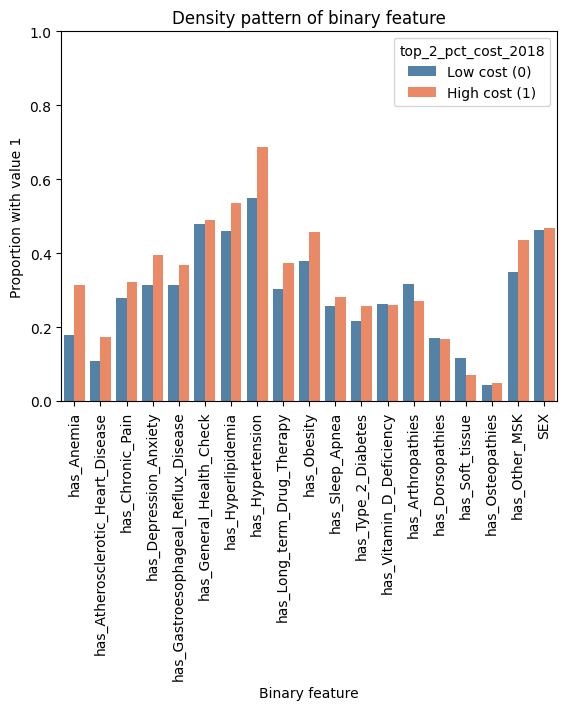

In [26]:
# Histogram/density of binary features: full data, with target (high vs low cost) as dodged bars
import matplotlib.pyplot as plt
import seaborn as sns

binary_cols = [c for c in feature_cols if train_pd[c].nunique()<=2 and c not in COST_COLUMNS]
print(binary_cols,len(binary_cols)) 
    # Proportion of value 1 for each binary feature, by target
props = []
for col in binary_cols:
    for tgt in [0, 1]:
        mask = train_pd[target_col] == tgt
        n = mask.sum()
        p = (train_pd.loc[mask, col] == 1).mean() if n > 0 else 0
        props.append({
            "feature": col,
            "target": "Low cost (0)" if tgt == 0 else "High cost (1)",
            "proportion": p,
        })
plot_df = pd.DataFrame(props)

p = sns.barplot(
    data=plot_df,
    x="feature",
    y="proportion",
    hue="target",
    hue_order=["Low cost (0)", "High cost (1)"],
    dodge=True,
    palette={"Low cost (0)": "steelblue", "High cost (1)": "coral"},
)
p.set_title(f"Density pattern of binary feature")
p.set_xlabel("Binary feature")
p.set_ylabel("Proportion with value 1")
p.tick_params(axis="x", rotation=90)
p.legend(title=target_col, loc="upper right")
p.set_ylim(0, 1)
plt.show()

NameError: name 'splits' is not defined

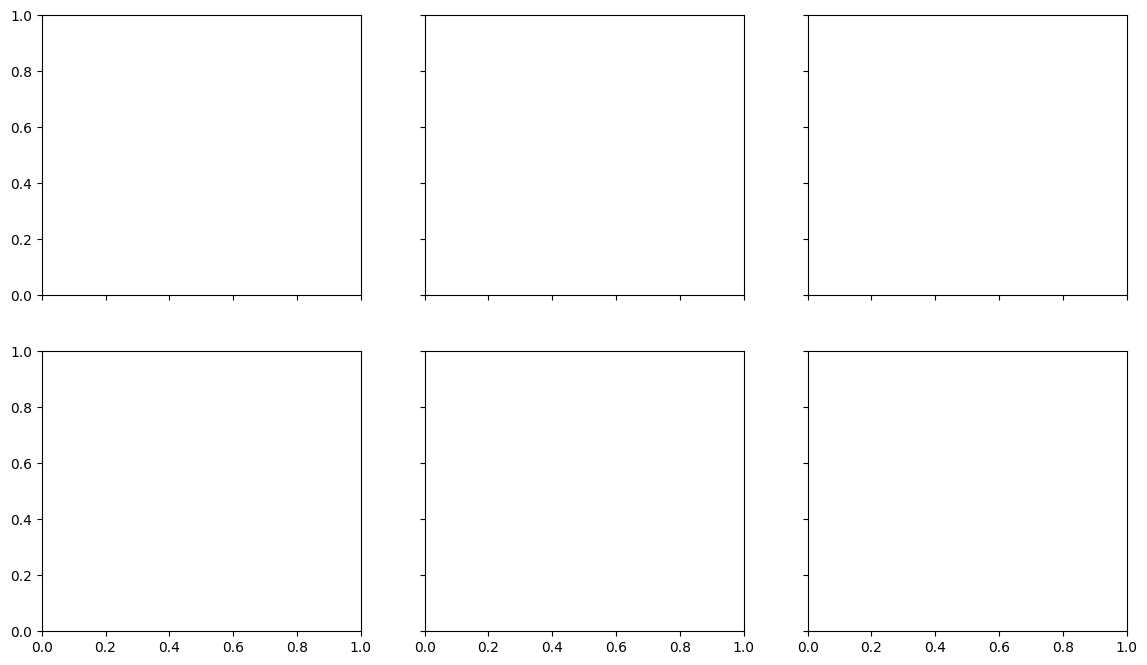

In [9]:
# X = proportion with value 1 (feature density), Y = count of features
# Histogram: how many binary features fall into each proportion bin
bins = np.linspace(0, 1, 50)
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
for row, tgt in enumerate([0, 1]):
    tgt_label = "Low cost (0)" if tgt == 0 else "High cost (1)"
    for col, (split_name, df_split) in enumerate(splits):
        ax = axes[row, col]
        mask = df_split[target_col] == tgt
        props = [(df_split.loc[mask, c] == 1).mean() for c in binary_cols if mask.sum() > 0]
        ax.hist(props, bins=bins, color="steelblue" if tgt == 0 else "coral", edgecolor="white", alpha=0.8)
        ax.set_title(f"{split_name} | {tgt_label}")
        ax.set_xlabel("Proportion with value 1")
        ax.set_ylabel("Count of features")
plt.suptitle("Feature density histogram: proportion with value 1 vs count of features", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# add plot where x axis is proportion with value 1 (density of feature) versus count of feature 

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def plot_majority_cost_by_metric(
    results_dir: str,
    csv_pattern: str = "exp*_*_s*.csv",
    target_col: str = "annual_cost_2018_deflated",
    filter_col: str = "top_2_pct_cost_2018",
) -> str:
    """
    Plot cost distribution (majority class) across methods.
    Exp 5 = 1N matched + 2N random; Exp 6 = 1N matched + 2N max-dispersed per metric.
    Returns path to saved plot.
    """
    base_path = Path(results_dir)
    all_files = list(base_path.glob("rnd_1to1_s*.csv")) + list(base_path.glob("ours_1to1_*.csv")) + list(base_path.glob("exp5_s*.csv")) + list(base_path.glob("exp6_*_s*.csv"))
    if not all_files:
        print(f"No sampling CSVs in {results_dir}")
        return ""

    data_list = []
    for f_path in all_files:

        fname = f_path.name.lower()
        print(fname)
        if "rnd_1to1_" in fname:
            method = "RND 1-1"
        elif "ours_1to1_s0" in fname:
            method = "Ours 1-1 old"
        elif "ours_1to1_a_za_v1" in fname:
            print("Found")
            method = "Ours 1-1 Z_A v1"
        elif "ours_1to1_a_za_coarse" in fname:
            print("Found")
            method = "Ours 1-1 Z_A coarse"
        elif "exp5_" in fname:
            method = "Exp 5 (1N matched + 2N random)"
        elif "exp6_" in fname:
            # Extract metric: exp6_euclidean_s0 -> Euclidean
            parts = fname.replace(".csv", "").split("_")
            if len(parts) >= 3:
                metric = parts[1]
                method = f"Exp 6 ({metric.capitalize()})"
            else:
                method = "Exp 6 (Unknown)"
        else:
            continue

        try:
            df = pd.read_csv(f_path, usecols=[target_col, filter_col])
            majority_df = df[df[filter_col] == 0].copy()
            majority_df["Method"] = method
            data_list.append(majority_df)
        except Exception as e:
            print(f"Skipping {fname}: {e}")

    if not data_list:
        print("No data for plotting.")
        return ""

    full_df = pd.concat(data_list, ignore_index=True)
    # Order: Exp 5 first (baseline), then Exp 6 metrics alphabetically
    base_order = ["RND 1-1", "Ours 1-1", "Exp 5 (1N matched + 2N random)"]
    rest = sorted([m for m in full_df["Method"].unique() if m not in base_order])
    method_order = [m for m in base_order if m in full_df["Method"].unique()] + rest
    full_df["Method"] = pd.Categorical(full_df["Method"], categories=method_order, ordered=True)
    full_df = full_df.sort_values("Method")

    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    palette = sns.color_palette("husl", n_colors=len(method_order))
    ax = sns.boxplot(data=full_df, x="Method", y=target_col, hue="Method", palette=dict(zip(method_order, palette)))
    plt.yscale("log")
    plt.title("Majority Class Cost Distribution: Exp 5 vs Exp 6 by Distance Metric\n(top_2_pct_cost_2018 == 0)", fontsize=14)
    plt.ylabel("Annual Cost 2018 (Log Scale $)")
    plt.xlabel("Sampling Method")
    plt.xticks(rotation=45, ha="right")
    plt.legend().set_visible(False)
    plt.tight_layout()
    out_path = os.path.join(results_dir, "exp6_cost_distribution_by_metric.png")
    plt.savefig(out_path, dpi=300)
    plt.close()
    print(f"Cost plot saved: {out_path}")
    return out_path

plot_majority_cost_by_metric(
    results_dir="../exp6_distance_ablation/results/",
    csv_pattern="exp6_*_s*.csv",
    target_col="annual_cost_2018_deflated",
    filter_col="top_2_pct_cost_2018"
)


rnd_1to1_s0.csv
ours_1to1_a_za_coarse_phenotype__b_zb_intensity_context.csv
Found
ours_1to1_s0.csv
ours_1to1_a_za_v1_flags_plus_counts__b_zb_intensity_context.csv
Found
exp5_s0.csv
exp6_gower_s0.csv
exp6_euclidean_s0.csv
exp6_manhattan_s0.csv
exp6_cosine_s0.csv
exp6_hamming_s0.csv
exp6_jaccard_s0.csv
exp6_chebyshev_s0.csv


/var/folders/mb/36y0j9bs5117v9zxrdzlbxkc0000gv/T/ipykernel_37316/889342400.py:79: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().set_visible(False)


Cost plot saved: ../exp6_distance_ablation/results/exp6_cost_distribution_by_metric.png


'../exp6_distance_ablation/results/exp6_cost_distribution_by_metric.png'